# 143. Reorder List

You are given the head of a singly linked-list. The list can be represented as:

L0 → L1 → … → Ln - 1 → Ln
Reorder the list to be on the following form:

L0 → Ln → L1 → Ln - 1 → L2 → Ln - 2 → …
You may not modify the values in the list's nodes. Only nodes themselves may be changed.

## Example 1:


Input: head = [1,2,3,4]
Output: [1,4,2,3]

## Example 2:

Input: head = [1,2,3,4,5]
Output: [1,5,2,4,3]
 
Constraints:

The number of nodes in the list is in the range [1, 5 * 104].
1 <= Node.val <= 1000

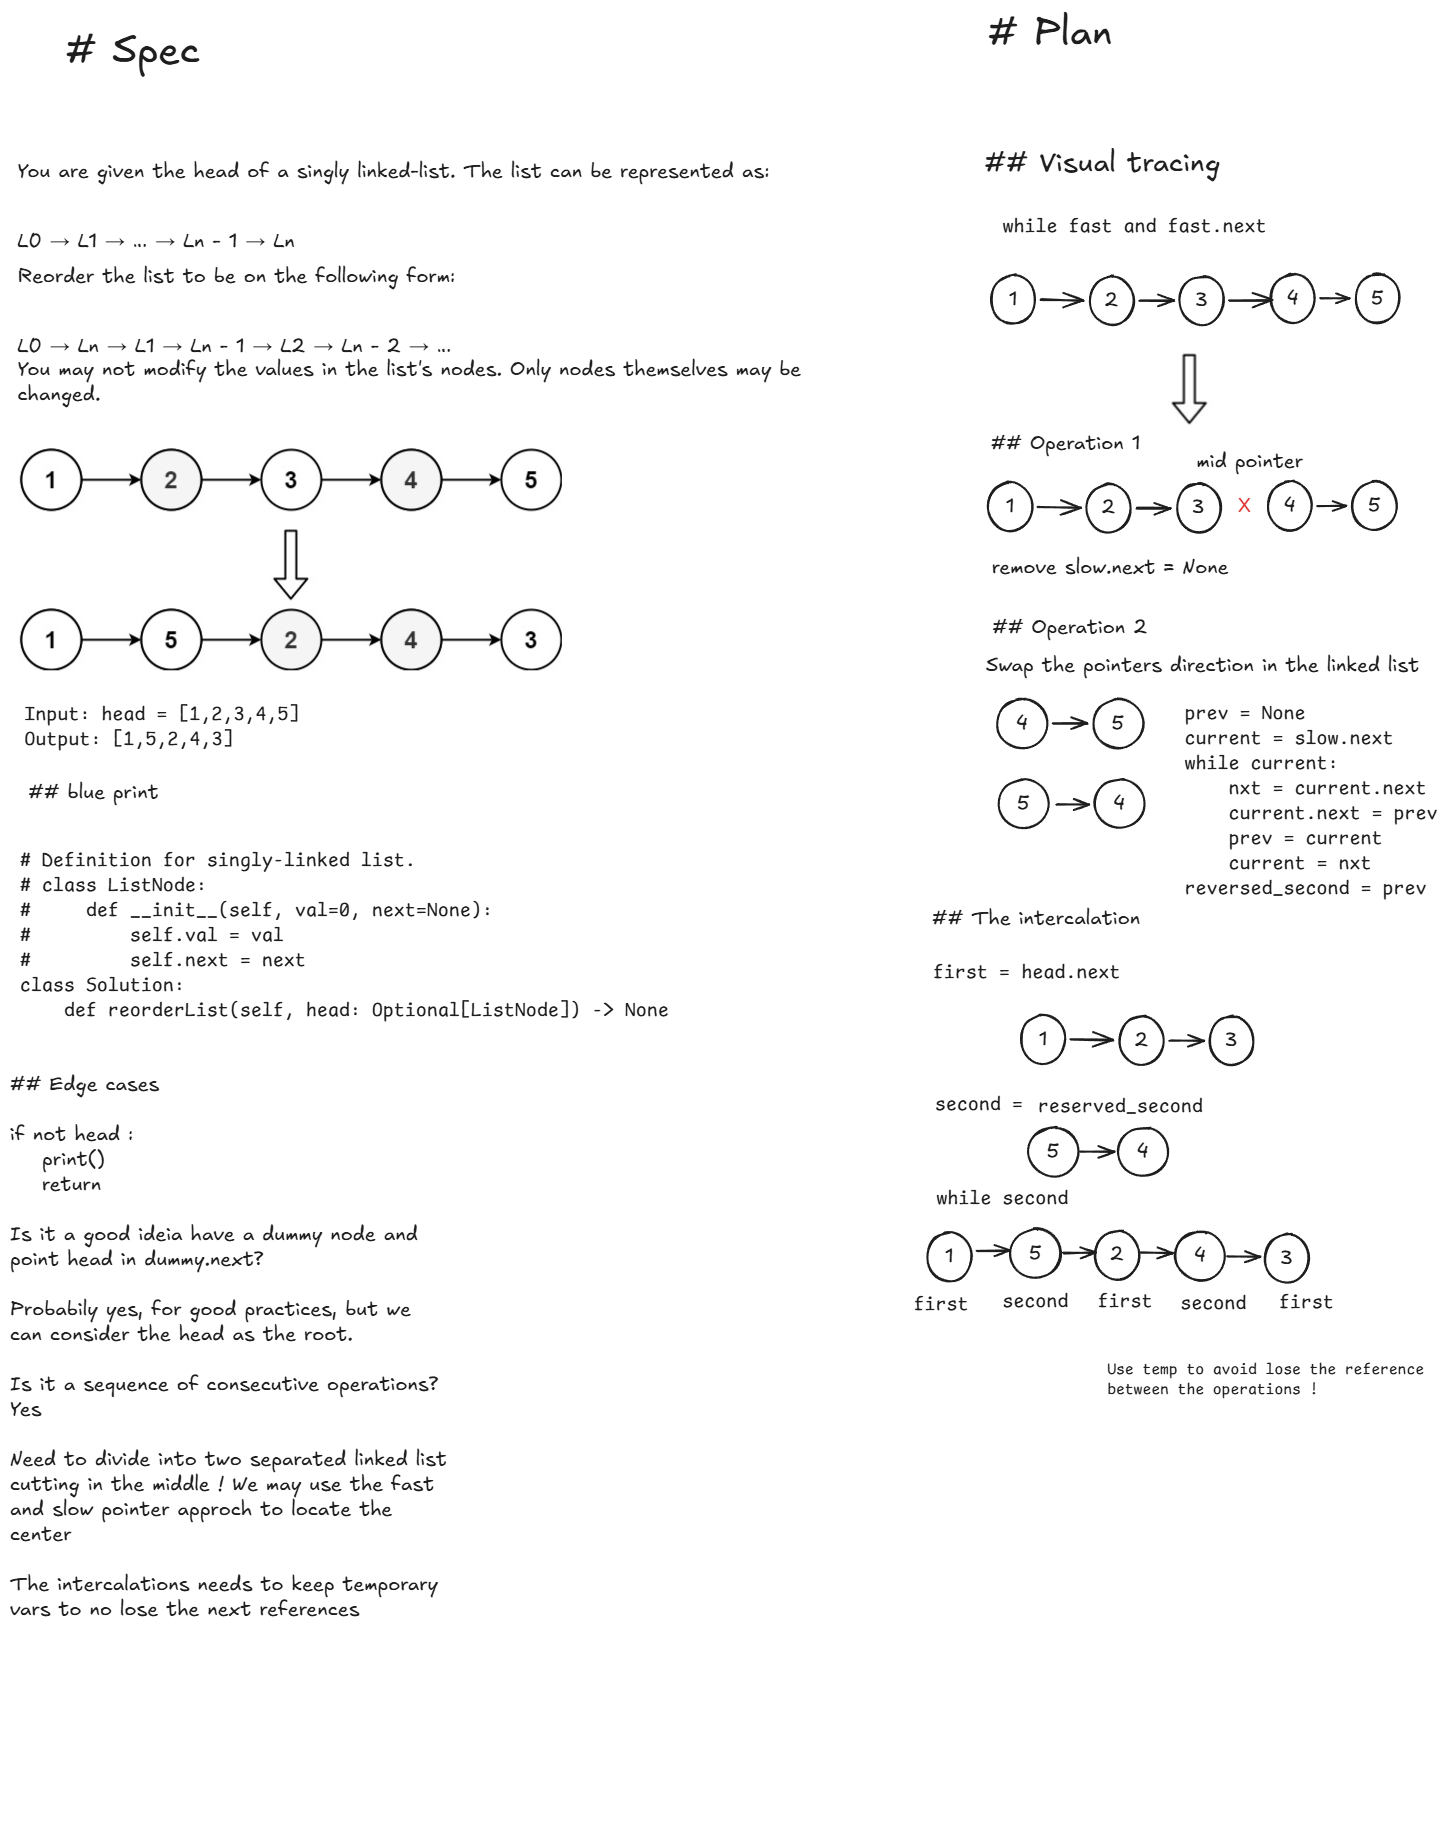

In [ ]:
from typing import Optional

class ListNode:
    def __init__(self, val=0, next=None):
        self.val = val
        self.next = next

class Solution:
    def reorderList(self, head: Optional[ListNode]) -> None:
        if not head or not head.next:
            return head

        # 1️⃣ Encontrar o meio da lista
        slow, fast = head, head
        while fast and fast.next:
            slow = slow.next
            fast = fast.next.next

        print(f"🌀 Meio encontrado em: {slow.val}")

        prev, current = None, slow.next
        slow.next = None

        print("\n🔁 Invertendo a segunda metade...")
        while current:
            nxt = current.next
            current.next = prev
            prev = current
            current = nxt

        second_half = prev
        print("Segunda metade invertida:")
        self.print_list(second_half)

        # 3️⃣ Intercalar as duas metades
        print("\n🔀 Intercalando listas...")
        first, second = head, second_half
        while second:
            nxt1, nxt2 = first.next, second.next
            first.next = second
            second.next = nxt1
            first, second = nxt1, nxt2

        print("\n✅ Lista final:")
        self.print_list(head)

    def print_list(self, head: Optional[ListNode]):
        current = head
        while current:
            print(current.val, end=" -> ")
            current = current.next
        print("None")


# 💡 Teste
head = ListNode(1, ListNode(2, ListNode(3, ListNode(4, None))))
sol = Solution()
print("Lista original:")
sol.print_list(head)

sol.reorderList(head)


Lista original:
1 -> 2 -> 3 -> 4 -> 5 -> None
🌀 Meio encontrado em: 3

🔁 Invertendo a segunda metade...
Segunda metade invertida:
5 -> 4 -> None

🔀 Intercalando listas...

✅ Lista final:
1 -> 5 -> 2 -> 4 -> 3 -> None
